In [333]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [334]:
# ========= 1. 實驗設定 (Configuration) =========

base_dir = r"c:\experiment\2D"

experiments = [
    {"file": os.path.join(base_dir, "t0185", "t0185.csv"), "group_val": 10, "group": "10cm"},
    {"file": os.path.join(base_dir, "t0184", "t0184v2.csv"), "group_val": 12.5, "group": "12.5cm"},
    {"file": os.path.join(base_dir, "t0183", "t0183.csv"), "group_val": 15, "group": "15cm"},
    {"file": os.path.join(base_dir, "t0186", "t0186.csv"), "group_val": 20, "group": "20cm"}
]

# 圖表 X 軸 (Normal Stress) 顯示範圍
xlim_min = 1
xlim_max = 9


In [335]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作為數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan



def process_data(target_metric):
    """ 讀取 CSV 並計算各組在每個 sigma 下的 median 與 IQR """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue
            
        df = pd.read_csv(exp['file'])
        
        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()
            
        if target_metric == 'k' and 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]

        
        if target_metric == 'shear_force' and 'delta_tau' in df.columns:
            # Force [kN] = delta_tau [MPa] * pi * r[cm]^2 * 0.1
            df['shear_force'] = df['delta_tau'] * np.pi * (exp['group_val'] ** 2) * 0.1

        if target_metric == 'delta_mu' and 'delta_mu' in df.columns:
            # mu_local = mu_global * (A_global / A_local)
            # A_global = 50 * 50 = 2500 cm^2
            # A_local = pi * r^2
            df['delta_mu'] = df['delta_mu'] * (2500 / (np.pi * (exp['group_val'] ** 2)))

        if target_metric not in df.columns:
            continue
            
        # 提取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])
        
        # 計算各個 sigma 的統計量
        stats = df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()
        
        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data


In [336]:
# ========= 3. 出版級繪製圖表函數 (Publication-Quality Plotting) =========
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import ScalarFormatter, NullFormatter
from scipy.optimize import curve_fit

PALETTE = ['#C96354', '#338EC4', '#E79F52', '#20854ECC', '#9391C1', '#8CADBD', '#FFE3A7', '#F170AC']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']
ALPHA = 1.0

def _apply_pub_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=11, width=1.0)
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight('bold')

def _style_colorbar(cbar, labels, label_text):
    cbar.set_label(label_text, fontsize=12, labelpad=8)
    cbar.ax.set_yticklabels(labels, fontsize=10)
    cbar.ax.tick_params(size=0)
    cbar.outline.set_linewidth(0.8)

def _errorbar_with_alpha(ax, x, y, yerr, color, marker, alpha=ALPHA):
    container = ax.errorbar(
        x, y, yerr=yerr,
        fmt=marker, color=color,
        markersize=5, capsize=7,
        markeredgecolor=color, markerfacecolor=color,
        markeredgewidth=1.3, capthick=1.3, elinewidth=1.3,
        zorder=4,
        alpha=alpha
    )
    return container

def _fit_power_law(ax, x, y, color, alpha=ALPHA):
    def power_law(xv, a, b): return a * (xv ** b)
    slope_init, intercept_init = np.polyfit(np.log(x), np.log(y), 1)
    p0 = [np.exp(intercept_init), slope_init]
    try: popt, _ = curve_fit(power_law, x, y, p0=p0, maxfev=10000)
    except: popt = p0
    a, b = popt
    ss_res = np.sum((y - power_law(x, a, b))**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 1.0
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * (x_line ** b)
    ln, = ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.3, zorder=3,
            label=f'$y={a:.2g}x^{{{b:.2g}}}$, $R^2={r2:.3f}$', alpha=alpha)

def _fit_linear(ax, x, y, color, alpha=ALPHA):
    slope, intercept = np.polyfit(x, y, 1)
    ss_res = np.sum((y - (slope * x + intercept))**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 1.0
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ln, = ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.3, zorder=3,
            label=f'm={slope:.3g}, $R^2={r2:.3f}$', alpha=alpha)

def plot_metric(target_metric, title, ylabel, loglog=False):
    data_to_plot = process_data(target_metric)
    if not data_to_plot: return
    n = len(data_to_plot)
    colors, mkrs = PALETTE[:n], MARKERS[:n]
    cmap_cb = ListedColormap(colors)
    norm_cb = BoundaryNorm([i - 0.5 for i in range(n)] + [n - 0.5], cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    all_sigmas = []
    for i, item in enumerate(data_to_plot):
        stats = item['stats']
        sigmas, medians = stats['sigma'].values, stats['median'].values
        yerr_lower, yerr_upper = medians - stats['q1'].values, stats['q3'].values - medians
        color, mk = colors[i], mkrs[i]
        all_sigmas.extend(sigmas)
        _errorbar_with_alpha(ax, sigmas, medians, [yerr_lower, yerr_upper], color, mk)
        if target_metric == 'shear_force' and len(sigmas) > 1:
            _fit_power_law(ax, sigmas, medians, color)
        elif len(sigmas) > 1:
            _fit_linear(ax, sigmas, medians, color)
    if loglog:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter()); ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter()); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]'); ax.set_ylabel(ylabel); ax.set_title(title)
    if loglog and all_sigmas: ax.set_xlim(min(all_sigmas) * 0.8, max(all_sigmas) * 1.2)
    else:
        try: ax.set_xlim(xlim_min, xlim_max)
        except: pass
    if all_sigmas: ax.set_xticks(np.unique(all_sigmas))
    _apply_pub_style(ax)
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30, pad=0.03)
    _style_colorbar(cbar, [item['group'] for item in data_to_plot], 'Seismogenic Zone Radius')
    plt.tight_layout()
    plt.show()

def plot_metric_by_group(target_metric, title, ylabel, loglog=False):
    group_order = [exp['group'] for exp in experiments]
    group_xval = {exp['group']: exp['group_val'] for exp in experiments}
    data_to_plot = process_data(target_metric)
    if not data_to_plot: return
    all_sigmas_set = set()
    for item in data_to_plot: all_sigmas_set.update(item['stats']['sigma'].values)
    unique_sigmas = sorted(all_sigmas_set)
    n = len(unique_sigmas)
    colors, mkrs = PALETTE[:n], MARKERS[:n]
    cmap_cb = ListedColormap(colors)
    norm_cb = BoundaryNorm([i - 0.5 for i in range(n)] + [n - 0.5], cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, sigma in enumerate(unique_sigmas):
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []
        for item in data_to_plot:
            group = item['group']
            if group not in group_xval: continue
            row = item['stats'][item['stats']['sigma'] == sigma]
            if row.empty: continue
            x_vals.append(group_xval[group])
            med = row['median'].values[0]
            y_vals.append(med)
            yerr_lo.append(med - row['q1'].values[0])
            yerr_hi.append(row['q3'].values[0] - med)
        if not x_vals: continue
        x_arr, y_arr = np.array(x_vals), np.array(y_vals)
        color, mk = colors[i], mkrs[i]
        _errorbar_with_alpha(ax, x_arr, y_arr, [np.array(yerr_lo), np.array(yerr_hi)], color, mk)
        if target_metric == 'shear_force' and len(x_arr) > 1:
            _fit_power_law(ax, x_arr, y_arr, color)
        elif len(x_arr) > 1:
            _fit_linear(ax, x_arr, y_arr, color)
    if loglog:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ScalarFormatter()); ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter()); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel('Seismogenic Zone Radius'); ax.set_ylabel(ylabel); ax.set_title(title)
    x_vals_all = list(group_xval.values())
    if loglog: ax.set_xlim(min(x_vals_all) * 0.8, max(x_vals_all) * 1.2)
    else: ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    ax.set_xticks(x_vals_all); ax.set_xticklabels(group_order)
    _apply_pub_style(ax)
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30, pad=0.03)
    _style_colorbar(cbar, [f'{s:.0f} MPa' for s in unique_sigmas], r'Normal Stress $\sigma$')
    plt.tight_layout()
    plt.show()


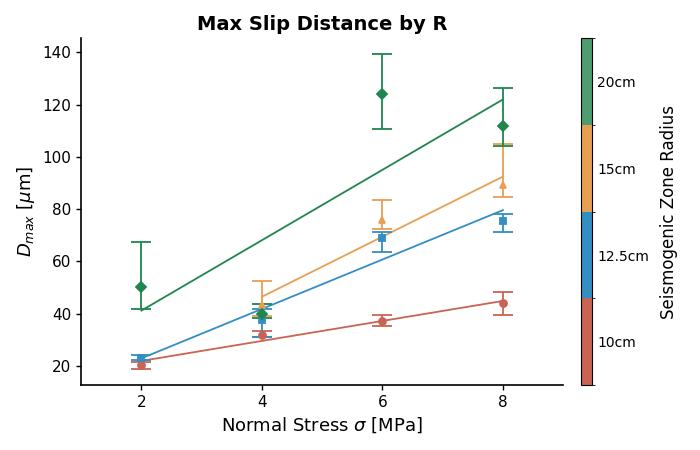

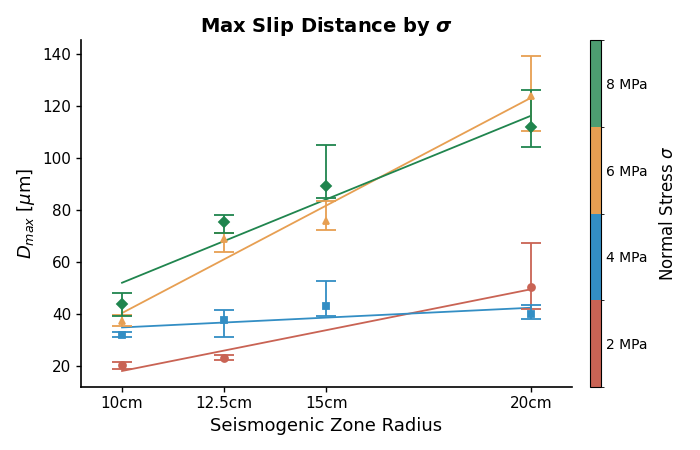

In [337]:
# === 繪製 D_max 圖 ===
plot_metric('D_max', r'Max Slip Distance by R', r'$D_{max}$ [$\mu$m]')
# === 以群組為 X 軸：D_max 圖 ===
plot_metric_by_group('D_max', r'Max Slip Distance by $\boldsymbol{\sigma}$', r'$D_{max}$ [$\mu$m]')

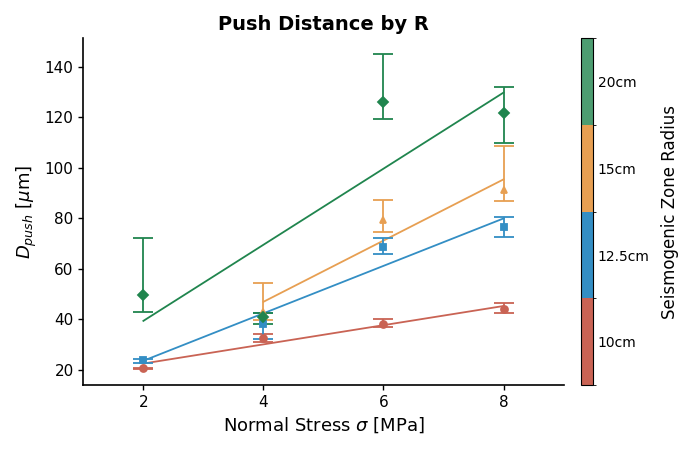

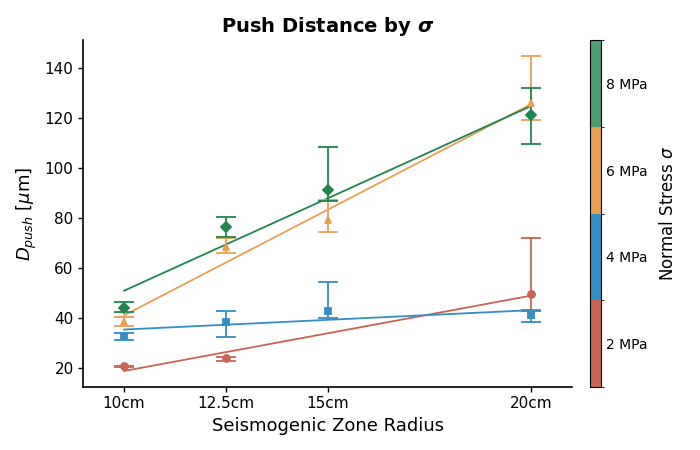

In [338]:
# === 繪製 D_Push 圖 ===
plot_metric('D_Push', r'Push Distance by R', r'$D_{push}$ [$\mu$m]')
# === 以群組為 X 軸：D_Push 圖 ===
plot_metric_by_group('D_Push', r'Push Distance by $\boldsymbol{\sigma}$', r'$D_{push}$ [$\mu$m]')

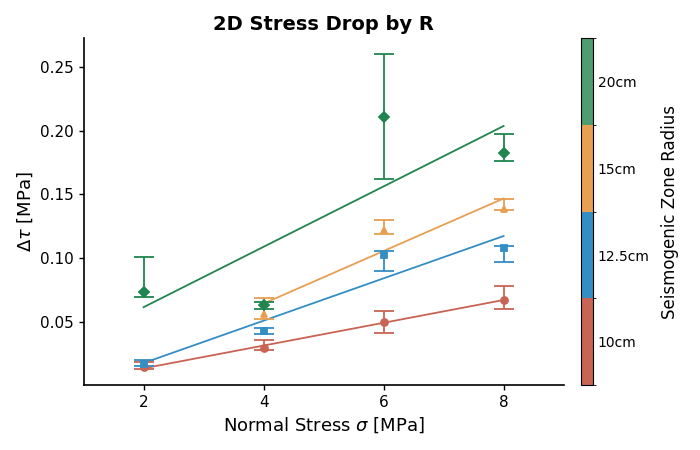

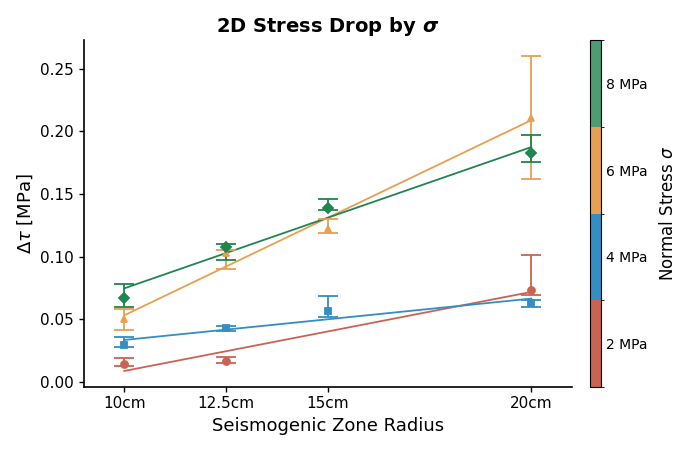

In [339]:
# === 繪製 Delta Tau 圖 ===
plot_metric('delta_tau', r'2D Stress Drop by R', r'$\Delta\tau$ [MPa]')
# === 以群組為 X 軸：Stress Drop 圖 ===
plot_metric_by_group('delta_tau', r'2D Stress Drop by $\boldsymbol{\sigma}$', r'$\Delta\tau$ [MPa]')


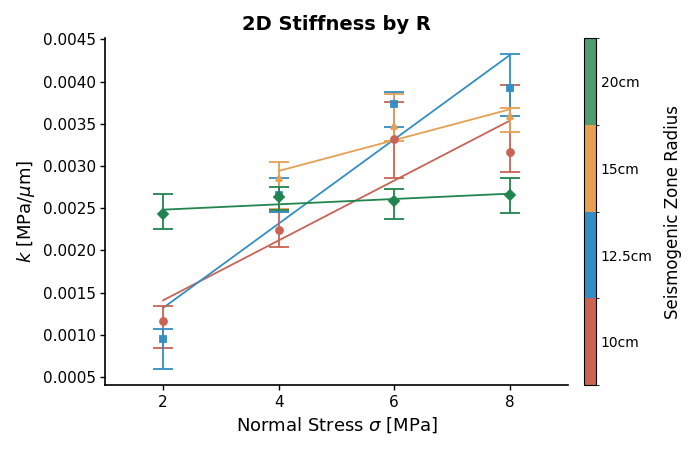

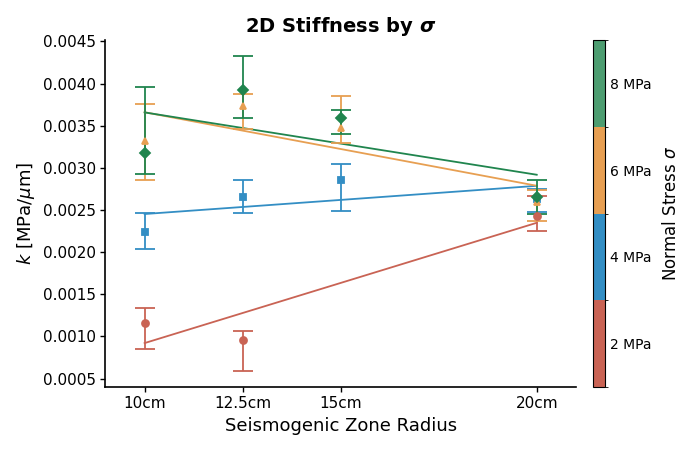

In [340]:
# === 繪製 Stiffness k 圖 ===
plot_metric('k', r'2D Stiffness by R', r'$k$ [MPa/$\mu$m]')
# === 以群組為 X 軸：Stiffness k 圖 ===
plot_metric_by_group('k', r'2D Stiffness by $\boldsymbol{\sigma}$', r'$k$ [MPa/$\mu$m]')


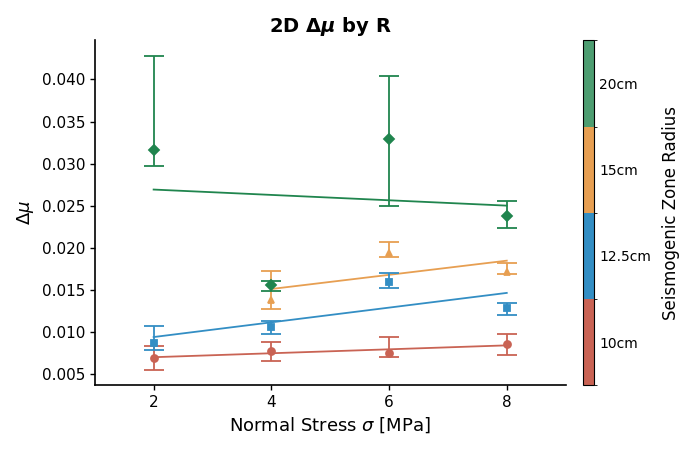

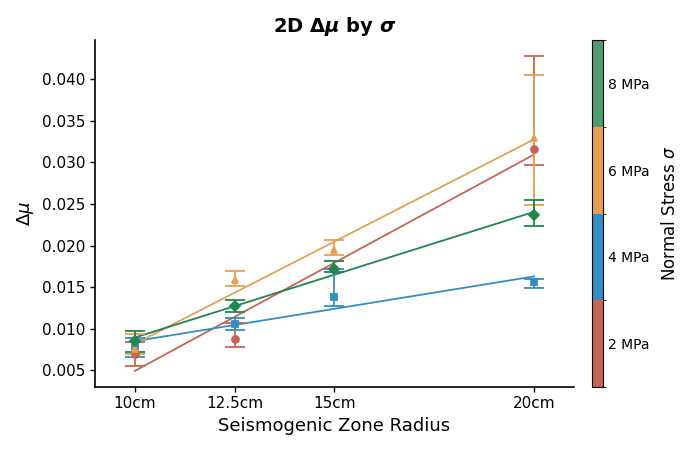

In [341]:
# ========= Delta Mu vs Normal Stress =========
plot_metric('delta_mu', r'2D $\boldsymbol{\Delta\mu}$ by R', r'$\Delta\mu$')
# ========= Delta Mu by Seismogenic Zone Radius =========
plot_metric_by_group('delta_mu', r'2D $\boldsymbol{\Delta\mu}$ by $\boldsymbol{\sigma}$', r'$\Delta\mu$')

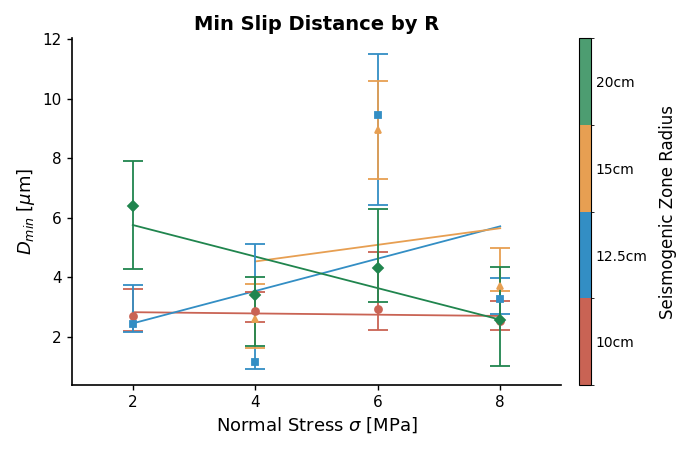

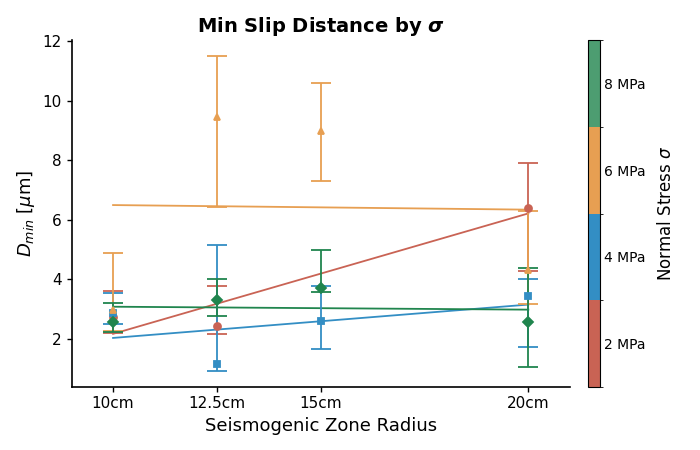

In [342]:
# ========= 畫 D_min (使用 LVDT 位移) 的圖表 =========
# 1. 畫以 Normal Stress (sigma) 為 X 軸的圖
plot_metric('delta_lvdt', r'Min Slip Distance by R', r'$D_{min}$ [$\mu$m]')
# 2. 畫以實驗群組為 X 軸的圖
plot_metric_by_group('delta_lvdt', r'Min Slip Distance by $\boldsymbol{\sigma}$', r'$D_{min}$ [$\mu$m]')

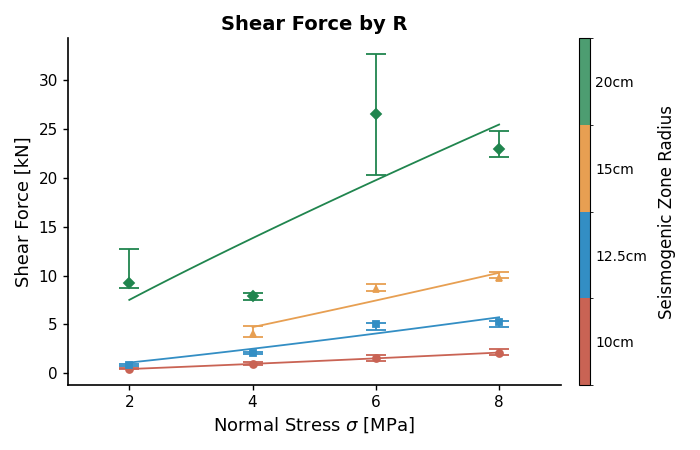

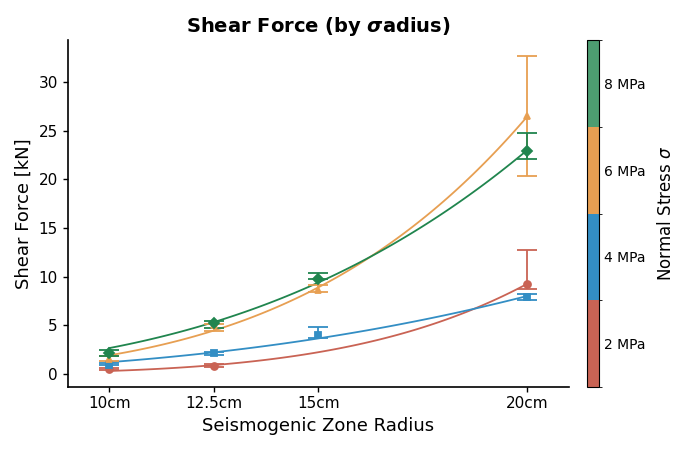

In [343]:
# === 繪製純剪力 (Shear Force) ===
# Shear Force [kN] = Stress Drop (delta_tau) [MPa] * pi * radius^2 * 0.1
plot_metric('shear_force', r'Shear Force by R', r'Shear Force [kN]')
plot_metric_by_group('shear_force', r'Shear Force (by $\boldsymbol{\sigma}$adius)', r'Shear Force [kN]')


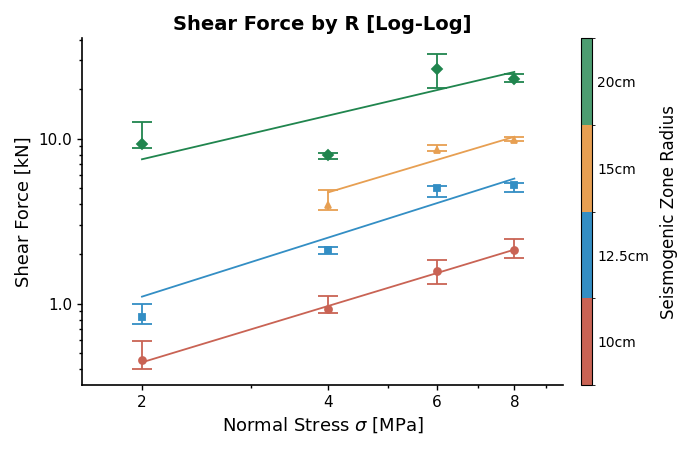

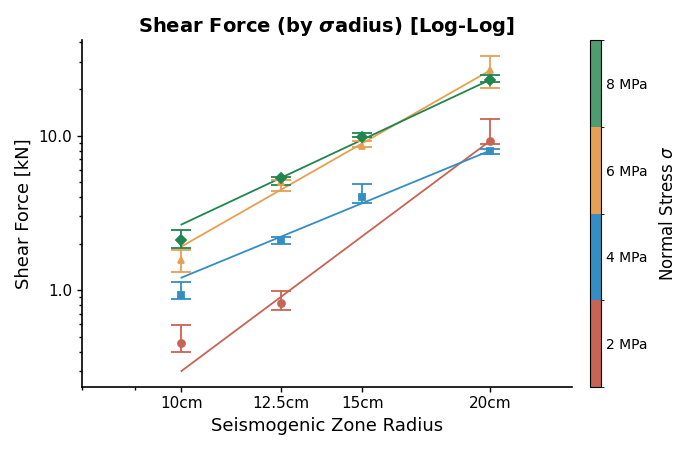

In [344]:
# === 繪製純剪力 (Shear Force) 的 Log-Log 圖 ===
plot_metric('shear_force', r'Shear Force by R [Log-Log]', r'Shear Force [kN]', loglog=True)
plot_metric_by_group('shear_force', r'Shear Force (by $\boldsymbol{\sigma}$adius) [Log-Log]', r'Shear Force [kN]', loglog=True)
